<a href="https://colab.research.google.com/github/adityab-tech/Machine-Unlearning/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install redivis

In [ ]:
import pandas as pd


In [ ]:
import os
#os.environ["REDIVIS_API_TOKEN"] = "my api"

In [ ]:
import redivis
organization = redivis.organization("AIMI")
dataset = organization.dataset("chexpert_plus")
print(dataset)

<Dataset AIMI.chexpert_plus>


In [ ]:
for table in dataset.list_tables():
    print(table)

Please delete the token on Redivis and remove it from your code, and follow the authentication prompts here instead.

This environment variable should only ever be set in a non-interactive environment, such as in an automated script or service.

<Table aimi.chexpert_plus:5yyj:v1_0.dicom_train:1934>
<Table aimi.chexpert_plus:5yyj:v1_0.png_valid:41v9>
<Table aimi.chexpert_plus:5yyj:v1_0.radgraph_xl_annotations:8wdv>
<Table aimi.chexpert_plus:5yyj:v1_0.df_chexpert_plus_240401:bavj>
<Table aimi.chexpert_plus:5yyj:v1_0.dicom_compressed:hc3k>
<Table aimi.chexpert_plus:5yyj:v1_0.dicom_valid:mg73>
<Table aimi.chexpert_plus:5yyj:v1_0.chexpert_labels:pmec>
<Table aimi.chexpert_plus:5yyj:v1_0.png_train:s6cj>
<Table aimi.chexpert_plus:5yyj:v1_0.png_compressed:wsd7>


In [ ]:
!pip install -U redivis pyarrow

In [ ]:
table.download("metadata.csv")

  0%|          | 0.00/100 [00:00<?, ?%/s]

0/1 files:   0%|          | 0.00/405M [00:00<?, ?B/s]

['metadata.csv']

In [ ]:
df = pd.read_csv("metadata.csv")
df.head()

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
0,train/patient00003/study1/view1_frontal.jpg,train/patient00003/study1/view1_frontal.dcm,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...","\nCHEST, ONE VIEW: 2-10-2001\n",NaN,NaN,...,\nLFEWOZWVDRX\nThis report has been anonymized...,41.0,Male,White,Non-Hispanic/Non-Latino,Unknown,Private Insurance,NaN,No,train
1,train/patient00007/study2/view1_frontal.jpg,train/patient00007/study2/view1_frontal.dcm,Frontal,AP,patient00007,2,NARRATIVE:\nChest 1 View: July 20\n \nHISTORY:...,\nChest 1 View: July 20\n \n,NaN,"Male, 69 years old, intubated.\n \n",...,\n485K2I4588\nThis report has been anonymized....,69.0,Male,Other,Hispanic/Latino,No,Private Insurance,NaN,No,train
2,train/patient00007/study1/view1_frontal.jpg,train/patient00007/study1/view1_frontal.dcm,Frontal,AP,patient00007,1,NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTO...,\nChest 1 View: 12-28-2000\n \n,NaN,"Male, 69 years old, Check tube placement.\n \n",...,\nRN\nThis report has been anonymized. All dat...,69.0,Male,Other,Hispanic/Latino,No,Private Insurance,NaN,No,train
3,train/patient00009/study1/view2_lateral.jpg,train/patient00009/study1/view2_lateral.dcm,Lateral,NaN,patient00009,1,NARRATIVE:\nCHEST X-RAY: 2/21/2006\nCOMPARISON...,\nCHEST X-RAY: 2/21/2006\n,Dyspnea. Multiple myeloma.\n,NaN,...,\n6340977630\nThis report has been anonymized....,76.0,Male,Asian,Non-Hispanic/Non-Latino,Unknown,Medicare,NaN,No,train
4,train/patient00009/study1/view1_frontal.jpg,train/patient00009/study1/view1_frontal.dcm,Frontal,PA,patient00009,2,NARRATIVE:\nCHEST X-RAY: 4/27/07\nCOMPARISON: ...,\nCHEST X-RAY: 4/27/07\n,Dyspnea. Multiple myeloma.\n,NaN,...,\n#624515709\nThis report has been anonymized....,76.0,Male,Asian,Non-Hispanic/Non-Latino,Unknown,Medicare,NaN,No,train


In [ ]:
print(df.shape)

(223462, 27)


In [ ]:
df.describe()

,patient_report_date_order,age,recent_bmi
count,223462.000000,223184.000000,164985.000000
mean,5.360656,60.390938,26.731495
std,7.418718,17.770630,6.510710
min,1.000000,0.000000,0.000000
25%,1.000000,49.000000,22.300000
50%,3.000000,62.000000,25.700000
75%,6.000000,74.000000,30.000000
max,92.000000,89.000000,50.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223462 entries, 0 to 223461
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   path_to_image               223462 non-null  object 
 1   path_to_dcm                 223462 non-null  object 
 2   frontal_lateral             223462 non-null  object 
 3   ap_pa                       191071 non-null  object 
 4   deid_patient_id             223462 non-null  object 
 5   patient_report_date_order   223462 non-null  int64  
 6   report                      223462 non-null  object 
 7   section_narrative           223434 non-null  object 
 8   section_clinical_history    138866 non-null  object 
 9   section_history             38192 non-null   object 
 10  section_comparison          213125 non-null  object 
 11  section_technique           10732 non-null   object 
 12  section_procedure_comments  25669 non-null   object 
 13  section_findin

In [ ]:
df.isnull().sum()

,0
path_to_image,0
path_to_dcm,0
frontal_lateral,0
ap_pa,32391
deid_patient_id,0
patient_report_date_order,0
report,0
section_narrative,28
section_clinical_history,84596
section_history,185270


In [ ]:
df["split"].value_counts()

,count
split,
train,223228
valid,234


In [ ]:
df["sex"].value_counts()

,count
sex,
Male,132482
Female,90701
Unknown,279


In [ ]:
print(df["report"].duplicated().sum())

2


In [ ]:
df = df.drop_duplicates(subset=["report"])

In [ ]:
df["report"].duplicated().sum()

np.int64(0)

In [ ]:
df["deid_patient_id"].nunique()

64725

In [ ]:
df = df.rename(columns={"deid_patient_id": "died_patient_id"})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223460 entries, 0 to 223461
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   path_to_image               223460 non-null  object 
 1   path_to_dcm                 223460 non-null  object 
 2   frontal_lateral             223460 non-null  object 
 3   ap_pa                       191071 non-null  object 
 4   died_patient_id             223460 non-null  object 
 5   patient_report_date_order   223460 non-null  int64  
 6   report                      223460 non-null  object 
 7   section_narrative           223432 non-null  object 
 8   section_clinical_history    138866 non-null  object 
 9   section_history             38192 non-null   object 
 10  section_comparison          213124 non-null  object 
 11  section_technique           10732 non-null   object 
 12  section_procedure_comments  25669 non-null   object 
 13  section_findings   

In [ ]:
df.describe(include='all')

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,died_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
count,223460,223460,223460,191071,223460,223460.000000,223460,223432,138866,38192,...,223460,223182.000000,223460,223460,223460,223460,223460,164984.000000,223460,223460
unique,223460,223460,2,4,64725,NaN,223460,201343,93944,26424,...,175848,NaN,3,8,4,3,5,NaN,3,2
top,valid/patient64739/study1/view1_frontal.jpg,valid/patient64739/study1/view1_frontal.dcm,Frontal,AP,patient28746,NaN,NARRATIVE:\nCOMPARISON: 7-21-2005\n \nIMPRESSI...,\n,Trauma.\n,Critical care follow-up(ICU)\n \n,...,\n56637\nThis report has been anonymized. All ...,NaN,Male,White,Non-Hispanic/Non-Latino,No,Medicare,NaN,No,train
freq,1,1,191071,161622,92,NaN,1,5483,301,43,...,776,NaN,132480,126668,169885,165936,107200,NaN,132036,223226
mean,NaN,NaN,NaN,NaN,NaN,5.360686,NaN,NaN,NaN,NaN,...,NaN,60.390950,NaN,NaN,NaN,NaN,NaN,26.731456,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,7.418745,NaN,NaN,NaN,NaN,...,NaN,17.770497,NaN,NaN,NaN,NaN,NaN,6.510711,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,49.000000,NaN,NaN,NaN,NaN,NaN,22.300000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,...,NaN,62.000000,NaN,NaN,NaN,NaN,NaN,25.700000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,...,NaN,74.000000,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN


In [ ]:
df["died_patient_id"].value_counts().describe()

,count
count,64725.000000
mean,3.452453
std,4.651213
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,92.000000


In [ ]:
df["report_length"] = df["report"].str.split().str.len()

In [ ]:
df["report_length"].describe()

,report_length
count,223460.000000
mean,117.365766
std,39.862758
min,36.000000
25%,92.000000
50%,110.000000
75%,132.000000
max,828.000000


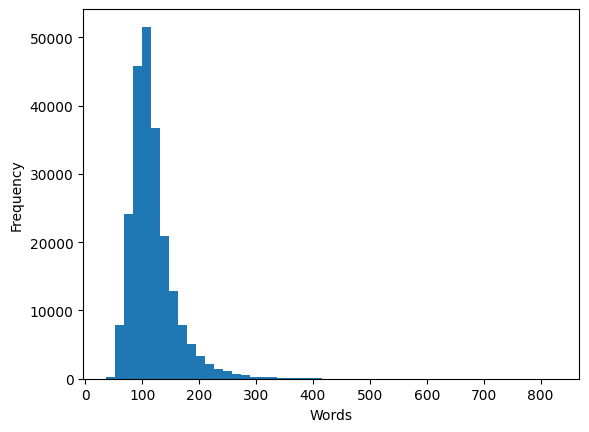

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df["report_length"], bins=50)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [62]:
#sab position ha jaha se chest x ray ghusa hai ..like ap mai aage se ,pa mai peeche se
df["ap_pa"].value_counts()

,count
ap_pa,
AP,161622
PA,29432
LL,16
RL,1


In [ ]:
df["ap_pa"].value_counts(dropna=False)

,count
ap_pa,
AP,161622
NaN,32389
PA,29432
LL,16
RL,1


In [67]:
df["race"].describe()

,race
count,223460
unique,8
top,White
freq,126668


In [73]:
df["race"].value_counts(dropna=False)

,count
race,
White,126668
Other,31560
Unknown,25370
Asian,23719
Black,12062
Pacific Islander,3180
Native American,547
Patient Refused,354
